In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
import pickle


COL_AE = '#2b83ba'
COL_PCA = '#d7191c'

In [2]:
# --- Utility Functions ---

def compute_errors(original, reconstructed):
    """Compute RMSE and NMSE between original and reconstructed data."""
    error = original - reconstructed
    rmse = np.sqrt(np.mean(error ** 2))
    nmse = ((error ** 2).mean(axis=1) / (original ** 2).mean(axis=1)).mean()
    return rmse, nmse

def load_reconstructed_data(file_path, index_col="ID"):
    """Load reconstructed data from a CSV file."""
    return pd.read_csv(file_path, index_col=index_col)

# --- Configuration ---

bottleneck_sizes = [2, 4, 8, 16, 32, 64, 100, 128]
force_recompute_pca = False  # Set to True to recompute PCA errors

# --- Load Data ---

df_scaled = pd.read_parquet("../data/census_data/engcensus_cleaned_scaled.parquet")
df_scaled.set_index(df_scaled.columns[0], inplace=True)

# --- Load Stability Results from Notebook 2 ---

stability_path = "../AE_outputs/retraining_stability_500epochs_linscaling/data/all_stability_results.pkl"
with open(stability_path, 'rb') as f:
    stability_results = pickle.load(f)

# Extract AE RMSE mean/std for each dimension
ae_rmse_means = [stability_results[dim]['rmse_mean'] for dim in bottleneck_sizes]
ae_rmse_stds = [stability_results[dim]['rmse_std'] for dim in bottleneck_sizes]

# Also extract min/max from per-run data
ae_rmse_mins = [np.min(stability_results[dim]['rmse_per_run']) for dim in bottleneck_sizes]
ae_rmse_maxs = [np.max(stability_results[dim]['rmse_per_run']) for dim in bottleneck_sizes]

print("Loaded AE stability results (10 runs per dimension)")

# --- Compute or Load PCA errors (deterministic, single run) ---

path = "../AE_outputs/engcensus_all/"
pca_cache_path = f"{path}pca_rmse_cache.pkl"

if os.path.exists(pca_cache_path) and not force_recompute_pca:
    print(f"Loading cached PCA errors from {pca_cache_path}")
    with open(pca_cache_path, 'rb') as f:
        pca_rmse = pickle.load(f)
else:
    print("Computing PCA errors...")
    pca_rmse = []
    for n in tqdm(bottleneck_sizes, desc="Processing PCA"):
        pca_reconstructed = load_reconstructed_data(f"{path}PCA/{n}_components.csv", index_col="OA")
        rmse, _ = compute_errors(df_scaled, pca_reconstructed)
        pca_rmse.append(rmse)
        print(f"PCA - {n} components: RMSE = {rmse:.4f}")
    
    # Cache PCA results
    with open(pca_cache_path, 'wb') as f:
        pickle.dump(pca_rmse, f)
    print(f"Saved PCA errors to {pca_cache_path}")

Loaded AE stability results (10 runs per dimension)
Loading cached PCA errors from ../AE_outputs/engcensus_all/pca_rmse_cache.pkl


In [3]:
# --- Summary Table ---

# Calculate coefficient of variation (CV) for each dimension
ae_cvs = [(std / mean) * 100 for mean, std in zip(ae_rmse_means, ae_rmse_stds)]

# Calculate how many stds the min and max are from the mean
min_stds_from_mean = [(mean - mn) / std for mean, mn, std in zip(ae_rmse_means, ae_rmse_mins, ae_rmse_stds)]
max_stds_from_mean = [(mx - mean) / std for mean, mx, std in zip(ae_rmse_means, ae_rmse_maxs, ae_rmse_stds)]

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Dimension': bottleneck_sizes,
    'PCA RMSE (%)': [r * 100 for r in pca_rmse],
    'AE Mean (%)': [r * 100 for r in ae_rmse_means],
    'AE Std (%)': [r * 100 for r in ae_rmse_stds],
    'AE Min (%)': [r * 100 for r in ae_rmse_mins],
    'AE Max (%)': [r * 100 for r in ae_rmse_maxs],
    'CV (%)': ae_cvs,
    'Min (σ from mean)': min_stds_from_mean,
    'Max (σ from mean)': max_stds_from_mean
})

# Format for display
summary_df_display = summary_df.copy()
for col in summary_df.columns[1:]:
    summary_df_display[col] = summary_df[col].apply(lambda x: f"{x:.4f}")

print("\n" + "="*120)
print("RMSE Comparison: PCA vs Autoencoder (10 runs)")
print("="*120)
print(summary_df_display.to_string(index=False))
print("="*120)


RMSE Comparison: PCA vs Autoencoder (10 runs)
 Dimension PCA RMSE (%) AE Mean (%) AE Std (%) AE Min (%) AE Max (%) CV (%) Min (σ from mean) Max (σ from mean)
         2       5.4469      3.8752     0.0200     3.8345     3.8993 0.5150            2.0399            1.2066
         4       4.5662      3.1408     0.0079     3.1307     3.1538 0.2513            1.2801            1.6350
         8       3.7224      2.5161     0.0078     2.5082     2.5350 0.3096            1.0160            2.4274
        16       2.8150      2.0064     0.0110     1.9929     2.0244 0.5484            1.2269            1.6349
        32       2.0354      1.5678     0.0070     1.5570     1.5820 0.4471            1.5291            2.0365
        64       1.3590      1.1057     0.0030     1.0998     1.1107 0.2671            2.0078            1.7034
       100       0.9436      0.7939     0.0060     0.7835     0.8054 0.7550            1.7378            1.9183
       128       0.7234      0.6695     0.0093     0.6531

In [4]:
# --- Percentage Improvement of AE over PCA for all bottleneck sizes ---

perc_improvement = [
    ((pca - ae) / pca) * 100
    for pca, ae in zip(pca_rmse, ae_rmse_means)
]

improvement_df = pd.DataFrame({
    'Bottleneck Size': bottleneck_sizes,
    'PCA RMSE (%)': [r * 100 for r in pca_rmse],
    'AE Mean RMSE (%)': [r * 100 for r in ae_rmse_means],
    '% Improvement (AE over PCA)': perc_improvement
})

# Format for display
improvement_display = improvement_df.copy()
for col in improvement_df.columns[1:]:
    improvement_display[col] = improvement_df[col].apply(lambda x: f"{x:.2f}")

print("Percentage Improvement of AE over PCA")
print("="*70)
print(improvement_display.to_string(index=False))
print("="*70)
print(f"\nAverage improvement: {np.mean(perc_improvement):.2f}%")
print(f"Max improvement:    {np.max(perc_improvement):.2f}% (at dim={bottleneck_sizes[np.argmax(perc_improvement)]})")
print(f"Min improvement:    {np.min(perc_improvement):.2f}% (at dim={bottleneck_sizes[np.argmin(perc_improvement)]})")

Percentage Improvement of AE over PCA
 Bottleneck Size PCA RMSE (%) AE Mean RMSE (%) % Improvement (AE over PCA)
               2         5.45             3.88                       28.85
               4         4.57             3.14                       31.22
               8         3.72             2.52                       32.41
              16         2.82             2.01                       28.73
              32         2.04             1.57                       22.98
              64         1.36             1.11                       18.64
             100         0.94             0.79                       15.86
             128         0.72             0.67                        7.45

Average improvement: 23.27%
Max improvement:    32.41% (at dim=8)
Min improvement:    7.45% (at dim=128)


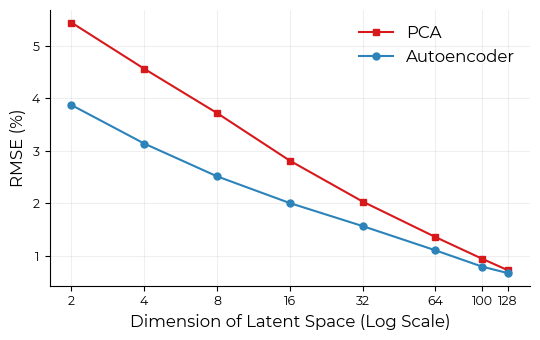

Saved: plots/pub_plots/rmse_vs_dimensions_publication_log_labelled_500ep.png and .pdf


In [5]:
# --- Publication Quality Plots (Log and Linear x-axis) ---

import matplotlib as mpl

# Use Montserrat font
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Montserrat']
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['legend.fontsize'] = 12

# Convert to arrays for plotting
ae_means = np.array(ae_rmse_means) * 100
ae_stds = np.array(ae_rmse_stds) * 100
pca_vals = np.array(pca_rmse) * 100
dims = np.array(bottleneck_sizes)

def make_rmse_plot(ax, log_x=False, label_log=False):
    """Draw the RMSE vs dimensions plot on the given axes."""
    # PCA (deterministic - no uncertainty)
    ax.plot(dims, pca_vals,
            marker='s', markersize=5, linewidth=1.5,
            label='PCA', color=COL_PCA, zorder=3)

    # AE with shaded error band
    ax.plot(dims, ae_means,
            marker='o', markersize=5, linewidth=1.5,
            label='Autoencoder', color=COL_AE, zorder=3)
    # ax.fill_between(dims, ae_means - ae_stds, ae_means + ae_stds,
    #                 alpha=0.3, color=COL_AE, linewidth=0,
    #                 label='AE ±1 std (n=10)')

    if log_x:
        ax.set_xscale('log', base=2)
    ax.set_xticks(bottleneck_sizes)
    ax.set_xticklabels(bottleneck_sizes)

    xlabel = 'Dimension of Latent Space'
    if label_log:
        xlabel += ' (Log Scale)'
    ax.set_xlabel(xlabel)
    ax.set_ylabel('RMSE (%)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='-', alpha=0.2, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, loc='upper right')

# # --- Linear x-axis version ---
# fig, ax = plt.subplots(figsize=(5.5, 3.5))
# make_rmse_plot(ax, log_x=False)
# plt.tight_layout()
# plt.savefig("plots/rmse_vs_dimensions_publication_linear_500ep.png", dpi=600, bbox_inches='tight')
# plt.savefig("plots/rmse_vs_dimensions_publication_linear_500ep.pdf", bbox_inches='tight')
# plt.show()
# print("Saved: plots/rmse_vs_dimensions_publication_linear_500ep.png and .pdf")

# --- Log x-axis version with log scale labelled ---
fig, ax = plt.subplots(figsize=(5.5, 3.5))
make_rmse_plot(ax, log_x=True, label_log=True)
plt.tight_layout()
plt.savefig("plots/pub_plots/rmse_vs_dimensions_publication_log_labelled_500ep.png", dpi=600, bbox_inches='tight')
plt.savefig("plots/pub_plots/rmse_vs_dimensions_publication_log_labelled_500ep.pdf", bbox_inches='tight')
plt.show()
print("Saved: plots/pub_plots/rmse_vs_dimensions_publication_log_labelled_500ep.png and .pdf")